In [3]:
import pandas as pd
from load import create_dataset
from features import build_features
from models import NaiveMLR, evaluate_forecast, compute_metrics

peco_coords_dict = {
    "PHL": (39.872, -75.241),
    "KOP": (40.096, -75.385),
    "West_Chester": (39.960, -75.605),
    "Coatesville": (39.983, -75.823),
    "Doylestown": (40.310, -75.130),
    "Pottstown": (40.245, -75.649),
    "Quakertown": (40.441, -75.340),
    "Levittown": (40.155, -74.855)
}

# ── Load real data: train on 2016-2022, test on 2023 ─────────────────────────
# Uses Open-Meteo ERA5 weather (cached after first fetch)
df = create_dataset("hrl_load_metered_combined.csv", "PE", LAT, LON)

df_train = df.loc["2016":"2022"]
df_test  = df.loc["2023"]

print(f"Train: {df_train.index[0].date()} → {df_train.index[-1].date()}  ({len(df_train):,} rows)")
print(f"Test : {df_test.index[0].date()}  → {df_test.index[-1].date()}  ({len(df_test):,} rows)")
print(f"NaNs in train temp: {df_train['temp'].isna().sum()}")
print(f"NaNs in test  temp: {df_test['temp'].isna().sum()}")

# ── 1. Feature matrix sanity check ───────────────────────────────────────────
X_train, y_train = build_features(df_train)
print(f"\nX_train shape : {X_train.shape}  (expect 281 cols)")
assert X_train.shape[1] == 281

# ── 2. Single fit → predict full test year ───────────────────────────────────
model = NaiveMLR()
preds = model.fit_predict(df_train, df_test)

metrics = compute_metrics(df_test["load_mw"], preds)
print("\n── Single-fit metrics (train 2016-22, test 2023) ──")
for k, v in metrics.items():
    print(f"  {k:6s}: {v:.3f}")

# # ── 3. Rolling forecast on 2023 (retrain each day) ───────────────────────────
# # Note: this retrains 365 times — takes a few minutes on real data
# results = rolling_forecast(
#     df,
#     forecast_start=pd.Timestamp("2023-01-01"),
#     forecast_end=pd.Timestamp("2023-12-31"),
# )

# print("\n── Rolling forecast metrics (2023) ──")
# roll_metrics = evaluate_forecast(results)
# for k, v in roll_metrics.items():
#     print(f"  {k:6s}: {v:.3f}")

# # ── 4. Breakdown by month ─────────────────────────────────────────────────────
# from models import compute_metrics
# monthly = compute_metrics(results["load_mw_actual"], results["load_mw_pred"], groupby="month")
# print("\n── MAPE by month (rolling) ──")
# months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
# for m, name in enumerate(months, start=1):
#     if m in monthly:
#         print(f"  {name}: {monthly[m]['MAPE']:.2f}%")


NameError: name 'LAT' is not defined

In [ ]:
import matplotlib.pyplot as plt
start_time = pd.Timestamp("2023-12-18")
end_time = pd.Timestamp("2023-12-31")
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(preds[start_time:end_time], label="Predicted Load (MW)", color='orange')
ax2 = ax.twinx()
ax2.plot(df_test["temp"][start_time:end_time], label="Temperature (°C)", color='green')
ax.plot(df_test["load_mw"][start_time:end_time], label="Actual Load (MW)", color='blue')
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.set_title("Predicted vs Actual Load (2023)")
ax.legend()
plt.grid(True)
plt.show()

In [ ]:

# ── Benchmark: compare weather location × season ─────────────────────────────
import pandas as pd
from load import create_dataset
from models import NaiveMLR, compute_metrics

SEASONS = {
    'Winter': [12, 1, 2],
    'Spring': [3, 4, 5],
    'Summer': [6, 7, 8],
    'Fall':   [9, 10, 11],
}

peco_coords_dict = {
    "PHL":         (39.877, -75.225),
    "KOP":         (40.097, -75.386),
    "West_Chester":(39.960, -75.605),
    "Coatesville": (39.983, -75.826),
    "Doylestown":  (40.310, -75.130),
    "Pottstown":   (40.245, -75.649),
    "Quakertown":  (40.441, -75.344),
    "Levittown":   (40.155, -74.830),
}

records = []
for loc_name, (lat, lon) in peco_coords_dict.items():
    print(f"Running {loc_name} ({lat}, {lon})...")
    df_loc   = create_dataset("hrl_load_metered_combined.csv", "PE", lat, lon)
    df_train = df_loc.loc["2016":"2022"]
    df_test  = df_loc.loc["2023"]

    model = NaiveMLR()
    preds = model.fit_predict(df_train, df_test)

    overall = compute_metrics(df_test["load_mw"], preds)

    row = {
        "Location": loc_name,
        "MAE":    round(overall["MAE"],    1),
        "RMSE":   round(overall["RMSE"],   1),
        "MAPE":   round(overall["MAPE"],   3),
        "CVRMSE": round(overall["CVRMSE"], 3),
    }
    for season, months in SEASONS.items():
        mask = df_test.index.month.isin(months)
        m = compute_metrics(df_test.loc[mask, "load_mw"], preds[mask])
        row[f"MAPE_{season}"] = round(m["MAPE"], 3)

    records.append(row)

results_df = pd.DataFrame(records).set_index("Location")
print("\nDone.")
results_df


In [ ]:

# ── Visualise: overall MAPE + seasonal heatmap ───────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

season_cols = [f"MAPE_{s}" for s in SEASONS]
season_labels = list(SEASONS.keys())
locations = results_df.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: grouped bar chart (overall + 4 seasons) ────────────────────────────
bar_cols  = ["MAPE"] + season_cols
bar_names = ["Overall"] + season_labels
x = np.arange(len(locations))
width = 0.15

for i, (col, name) in enumerate(zip(bar_cols, bar_names)):
    offset = (i - len(bar_cols) / 2 + 0.5) * width
    axes[0].bar(x + offset, results_df[col], width, label=name)

axes[0].set_xticks(x)
axes[0].set_xticklabels(locations, rotation=30, ha="right")
axes[0].set_ylabel("MAPE (%)")
axes[0].set_title("MAPE by Location and Season (test year 2023)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.4)

# ── Right: heatmap of seasonal MAPE ──────────────────────────────────────────
data = results_df[season_cols].values
im = axes[1].imshow(data, aspect="auto", cmap="RdYlGn_r")
axes[1].set_xticks(range(len(season_labels)))
axes[1].set_xticklabels(season_labels)
axes[1].set_yticks(range(len(locations)))
axes[1].set_yticklabels(locations)
axes[1].set_title("Seasonal MAPE heatmap (%)")
plt.colorbar(im, ax=axes[1], label="MAPE (%)")

for r in range(len(locations)):
    for c in range(len(season_labels)):
        axes[1].text(c, r, f"{data[r, c]:.2f}", ha="center", va="center",
                     fontsize=8, color="black")

plt.tight_layout()
plt.show()


In [ ]:
from load import create_dataset
locations = [
    ("Philadelphia", 39.95, -75.16),
    ("Harrisburg",   40.27, -76.88),
    ("Allentown",    40.65, -75.43),
]

df = create_dataset("hrl_load_metered_2018.csv", "PE", locations)
# Columns: load_mw, philadelphia_temp, philadelphia_dwpt, ..., harrisburg_temp, ...


In [ ]:
df.head()

/tmp/ipykernel_20018/872935739.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw["timestamp"] = pd.to_datetime(raw["datetime_beginning_ept"])


Plotting week: 2023-06-03 → 2023-06-08


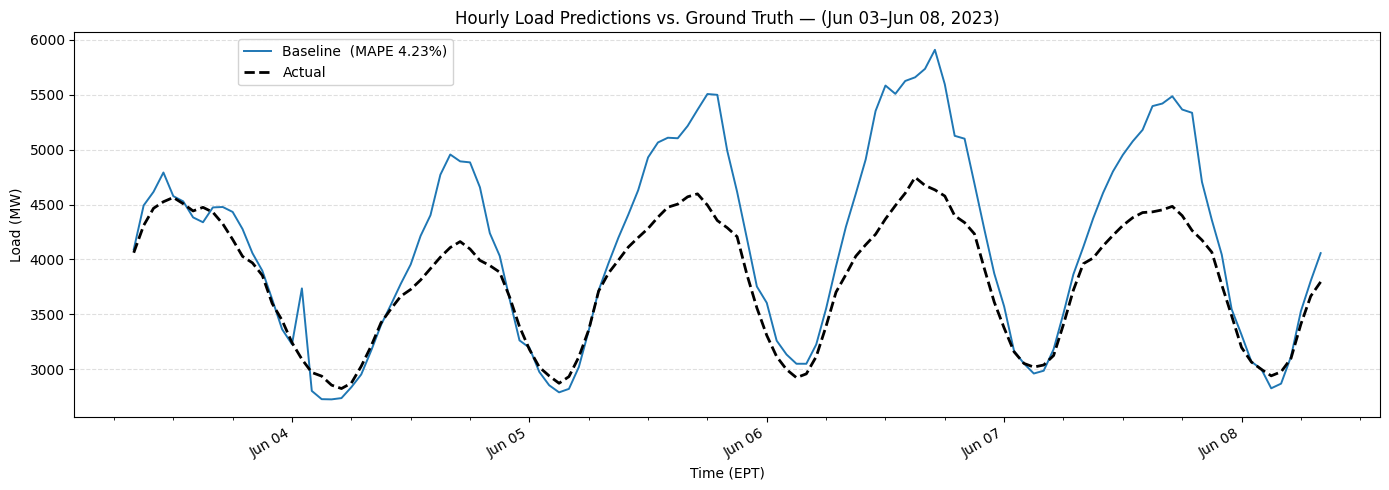

In [8]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Load actual 2023 load (Zone PE) ──────────────────────────────────────────
raw = pd.read_csv("data/raw/hrl_load_metered_combined.csv")
raw = raw[raw["zone"] == "PE"].copy()
raw["timestamp"] = pd.to_datetime(raw["datetime_beginning_ept"])
actual = raw.groupby("timestamp")["mw"].sum().rename("actual")
actual = actual[~actual.index.duplicated(keep="first")]

# ── Load all prediction files ─────────────────────────────────────────────────
models = {
    "Baseline":        "results/baseline_predictions.csv",
    "Weather":         "results/weather_predictions.csv",
    "Recency":         "results/recency_predictions.csv",
    "Recency+Weather": "results/recency-weather_predictions.csv",
    "Single-Station":  "results/single-station_predictions.csv",
}

preds = {}
for name, path in models.items():
    s = pd.read_csv(path, index_col=0, parse_dates=True)["load_mw_pred"]
    s.index.name = "timestamp"
    s = s[~s.index.duplicated(keep="first")]
    preds[name] = s

# ── Combine into one DataFrame ────────────────────────────────────────────────
combined = pd.DataFrame(preds)
combined = combined.join(actual, how="left")

# ── Compute full-year MAPE per model ─────────────────────────────────────────
mape = {
    name: (combined[name] - combined["actual"]).abs().div(combined["actual"]).mean() * 100
    for name in models
}

# ── Find worst summer week (highest mean absolute error across all models) ─────
summer = combined["2023-06-01":"2023-08-31"].copy()
pred_cols = ["Baseline"]
summer["mae"] = summer[pred_cols].sub(summer["actual"], axis=0).abs().mean(axis=1)

# Rolling 7-day mean MAE; pick the window ending at the peak
rolling_mae = summer["mae"].rolling(24 * 7).mean()
worst_end   = rolling_mae.idxmax()
worst_start = worst_end - pd.Timedelta(days=5)
week = combined[worst_start:worst_end]

print(f"Plotting week: {worst_start.date()} → {worst_end.date()}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for i, name in enumerate(pred_cols):
    label = f"{name}  (MAPE {mape[name]:.2f}%)"
    ax.plot(week.index, week[name], label=label, linewidth=1.4, color=colors[i])

ax.plot(week.index, week["actual"],
        label="Actual", color="black", linewidth=2, linestyle="--", zorder=10)

ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

ax.set_title(f"Hourly Load Predictions vs. Ground Truth — "
             f"({worst_start.strftime('%b %d')}–{worst_end.strftime('%b %d, %Y')})")
ax.set_ylabel("Load (MW)")
ax.set_xlabel("Time (EPT)")
ax.legend(loc="upper left", bbox_to_anchor=(0.12, 1.0), framealpha=0.85)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


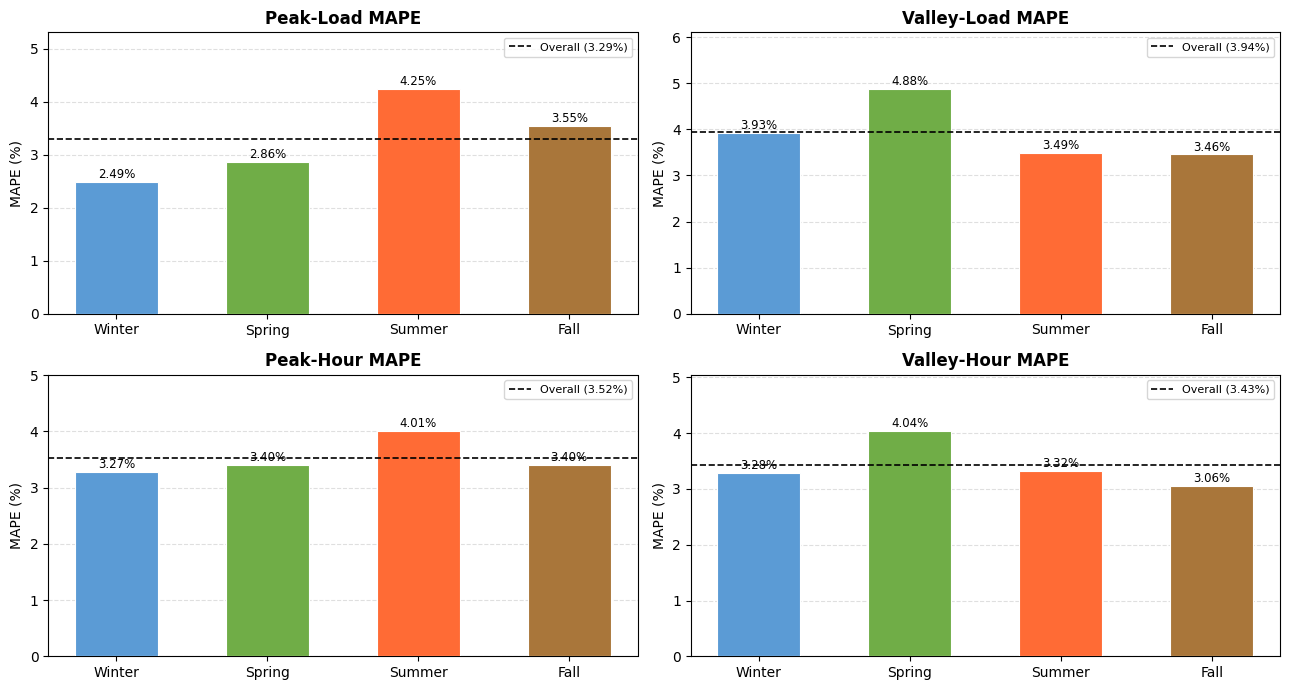

In [12]:

import json
import numpy as np
import matplotlib.pyplot as plt

with open("results/recency-weather.json") as f:
    data = json.load(f)

seasons  = ["Winter", "Spring", "Summer", "Fall"]
metrics  = ["peak_load_mape", "valley_load_mape", "peak_hour_load_mape", "valley_hour_load_mape"]
labels   = ["Peak-Load MAPE", "Valley-Load MAPE", "Peak-Hour MAPE", "Valley-Hour MAPE"]
colors   = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

season_colors = {
    "Winter": "#5B9BD5",
    "Spring": "#70AD47",
    "Summer": "#FF6B35",
    "Fall":   "#A9763A",
}

x      = np.arange(len(seasons))
width  = 0.18

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharey=False)
axes = axes.flatten()

for ax, metric, title, color in zip(axes, metrics, labels, colors):
    values = [data["metrics"][s][metric] for s in seasons]
    bars = ax.bar(x, values, width=0.55, color=[season_colors[s] for s in seasons],
                  edgecolor="white", linewidth=0.8, zorder=3)

    # annotate bar tops
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{v:.2f}%", ha="center", va="bottom", fontsize=8.5)

    # overall reference line
    overall_val = data["metrics"]["overall"][metric]
    ax.axhline(overall_val, color="black", linewidth=1.2, linestyle="--", zorder=4,
               label=f"Overall ({overall_val:.2f}%)")

    ax.set_xticks(x)
    ax.set_xticklabels(seasons)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("MAPE (%)")
    ax.legend(fontsize=8, framealpha=0.8)
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
    ax.set_ylim(0, max(values) * 1.25)

plt.tight_layout()
plt.show()
